In [ ]:
# Install required packages
!pip install -q tensorflow >=2.16.0
!pip install -q ultralytics
!pip install -q kaggle
!pip install -q opencv-python-headless
!pip install -q matplotlib seaborn scikit-learn

print("✓ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.5 MB/s eta 0:00:00
✓ All packages installed successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create directory for saving models
import os
os.makedirs('/content/drive/MyDrive/crop_models', exist_ok=True)
print("✓ Google Drive mounted successfully!")

Mounted at /content/drive
✓ Google Drive mounted successfully!


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omrathod2003/140-most-popular-crops-image-dataset")


# Extract dataset
!unzip -q 140-most-popular-crops-image-dataset.zip -d /content/dataset
print("✓ Dataset downloaded and extracted!")

100%|██████████| 11.9G/11.9G [02:21<00:00, 90.3MB/s]

Extracting files...


unzip:  cannot find or open 140-most-popular-crops-image-dataset.zip, 140-most-popular-crops-image-dataset.zip.zip or 140-most-popular-crops-image-dataset.zip.ZIP.
✓ Dataset downloaded and extracted!


In [ ]:
print(path)

/root/.cache/kagglehub/datasets/omrathod2003/140-most-popular-crops-image-dataset/versions/5


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import json
from datetime import datetime

# Configuration
CONFIG = {
    # Paths
    'DATASET_PATH': '/root/.cache/kagglehub/datasets/omrathod2003/140-most-popular-crops-image-dataset/versions/5/RGB_224x224/RGB_224x224',
    'MODEL_SAVE_PATH': '/content/drive/MyDrive/crop_models',

    # Model parameters
    'NUM_CLASSES': 17,
    'IMAGE_SIZE': 224,
    'BATCH_SIZE': 32,
    'EPOCHS': 100,
    'LEARNING_RATE': 0.001,

    # EfficientNet version: 'B0', 'B1', 'B2', 'B3' (B0 is fastest)
    'EFFICIENTNET_VERSION': 'B0',
    'DROPOUT_RATE': 0.3,

    # Training
    'USE_AUGMENTATION': True,
    'EARLY_STOPPING_PATIENCE': 10,
    'REDUCE_LR_PATIENCE': 5,
}

# Crop classes

CROP_CLASSES = [
    "Maize (Corn)","Potatoes","Wheat","Apples","Chili peppers and green peppers",
    "Cherry","Cucumbers and gherkins","Rice (Paddy)","Grapes","Groundnuts (Peanuts)","Guavas","Lemons and limes",
    "Peaches and nectarines","Pumpkins, squash and gourds","Strawberries","Tomatoes"
]

'''"Apples",
"Cherry",
"Cucumbers and gherkins",
"Grapes",
"Groundnuts (Peanuts)",
"Guavas",
"Lemons and limes",
"Maize (Corn)",
"Peaches and nectarines",
"Potatoes",
"Pumpkins, squash and gourds",
"Rice (Paddy)",
"Strawberries",
"Tomatoes",
"Wheat"
'''

'''apple///, cherry///, cucumber///, rice///,
 grape///, groundnut/, guava/////, lemon///, peach////, potato/////, pumpkin///, strawberry/////, tomato////, wheat/'''

print(f"✓ Configuration loaded")
print(f"  - Classes: {CONFIG['NUM_CLASSES']}")
print(f"  - Image Size: {CONFIG['IMAGE_SIZE']}x{CONFIG['IMAGE_SIZE']}")
print(f"  - Batch Size: {CONFIG['BATCH_SIZE']}")
print(f"  - Epochs: {CONFIG['EPOCHS']}")

✓ Configuration loaded
  - Classes: 17
  - Image Size: 224x224
  - Batch Size: 32
  - Epochs: 100


In [ ]:
# Verify dataset structure
def verify_dataset(dataset_path):
    """Verify dataset exists and has correct structure"""
    train_dir = os.path.join(dataset_path, 'train')
    val_dir = os.path.join(dataset_path, 'val')
    test_dir = os.path.join(dataset_path, 'test')

    print("Dataset Verification:")
    print("=" * 60)

    for split_name, split_dir in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
        if os.path.exists(split_dir):
            num_classes = len([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))])
            total_images = sum([len([f for f in os.listdir(os.path.join(split_dir, c))
                                    if f.endswith(('.jpg', '.png'))])
                               for c in os.listdir(split_dir)
                               if os.path.isdir(os.path.join(split_dir, c))])
            print(f"✓ {split_name:5s}: {num_classes} classes, {total_images:,} images")
        else:
            print(f"✗ {split_name:5s}: Not found!")

    print("=" * 60)

verify_dataset(CONFIG['DATASET_PATH'])

Dataset Verification:
✓ Train: 139 classes, 27,639 images
✓ Val  : 139 classes, 6,422 images
✓ Test : 139 classes, 6,627 images


In [ ]:
import shutil

# Remove duplicates from CROP_CLASSES
CROP_CLASSES = list(dict.fromkeys(CROP_CLASSES))  # Removes duplicates while preserving order
print(f"Classes after removing duplicates: {len(CROP_CLASSES)}")

# Create filtered dataset with only selected classes
FILTERED_DATASET_PATH = '/content/dataset_filtered'

# Remove existing filtered dataset if it exists
if os.path.exists(FILTERED_DATASET_PATH):
    shutil.rmtree(FILTERED_DATASET_PATH)
    print("✓ Removed existing filtered dataset")

for split in ['train', 'val', 'test']:
    src_split = os.path.join(CONFIG['DATASET_PATH'], split)
    dst_split = os.path.join(FILTERED_DATASET_PATH, split)
    os.makedirs(dst_split, exist_ok=True)

    for crop_class in CROP_CLASSES:
        src_class = os.path.join(src_split, f"{crop_class} plant")
        dst_class = os.path.join(dst_split, f"{crop_class} plant")

        if os.path.exists(src_class):
            shutil.copytree(src_class, dst_class)
            print(f"✓ Copied {crop_class}")
        else:
            print(f"⚠ Warning: {crop_class} not found in {split}")

# Update config to use filtered dataset
CONFIG['DATASET_PATH'] = FILTERED_DATASET_PATH
print(f"\n✓ Filtered dataset created with {len(CROP_CLASSES)} classes")

# Update NUM_CLASSES in config
CONFIG['NUM_CLASSES'] = len(CROP_CLASSES)
print(f"✓ NUM_CLASSES updated to {CONFIG['NUM_CLASSES']}")

Classes after removing duplicates: 16
✓ Removed existing filtered dataset
✓ Copied Maize (Corn)
✓ Copied Potatoes
✓ Copied Wheat
✓ Copied Apples
✓ Copied Chili peppers and green peppers
✓ Copied Cherry
✓ Copied Cucumbers and gherkins
✓ Copied Rice (Paddy)
✓ Copied Grapes
✓ Copied Groundnuts (Peanuts)
✓ Copied Guavas
✓ Copied Lemons and limes
✓ Copied Peaches and nectarines
✓ Copied Pumpkins, squash and gourds
✓ Copied Strawberries
✓ Copied Tomatoes
✓ Copied Maize (Corn)
✓ Copied Potatoes
✓ Copied Wheat
✓ Copied Apples
✓ Copied Chili peppers and green peppers
✓ Copied Cherry
✓ Copied Cucumbers and gherkins
✓ Copied Rice (Paddy)
✓ Copied Grapes
✓ Copied Groundnuts (Peanuts)
✓ Copied Guavas
✓ Copied Lemons and limes
✓ Copied Peaches and nectarines
✓ Copied Pumpkins, squash and gourds
✓ Copied Strawberries
✓ Copied Tomatoes
✓ Copied Maize (Corn)
✓ Copied Potatoes
✓ Copied Wheat
✓ Copied Apples
✓ Copied Chili peppers and green peppers
✓ Copied Cherry
✓ Copied Cucumbers and gherkins
✓ Copied

In [ ]:
def create_data_generators():
    """Create data generators for training, validation, and testing"""

    train_dir = os.path.join(CONFIG['DATASET_PATH'], 'train')
    val_dir = os.path.join(CONFIG['DATASET_PATH'], 'val')
    test_dir = os.path.join(CONFIG['DATASET_PATH'], 'test')

    # Training data generator with augmentation
    if CONFIG['USE_AUGMENTATION']:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            fill_mode='nearest'
        )
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)

    # Validation and test data generators (no augmentation)
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    # Create generators
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),
        batch_size=CONFIG['BATCH_SIZE'],
        class_mode='categorical',
        shuffle=True
    )

    val_generator = val_test_datagen.flow_from_directory(
        val_dir,
        target_size=(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),
        batch_size=CONFIG['BATCH_SIZE'],
        class_mode='categorical',
        shuffle=False
    )

    test_generator = val_test_datagen.flow_from_directory(
        test_dir,
        target_size=(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),
        batch_size=CONFIG['BATCH_SIZE'],
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

# Create generators
train_gen, val_gen, test_gen = create_data_generators()

print(f"✓ Data generators created")
print(f"  - Training samples: {train_gen.samples}")
print(f"  - Validation samples: {val_gen.samples}")
print(f"  - Test samples: {test_gen.samples}")

Found 3176 images belonging to 16 classes.
Found 697 images belonging to 16 classes.
Found 714 images belonging to 16 classes.
✓ Data generators created
  - Training samples: 3176
  - Validation samples: 697
  - Test samples: 714


In [ ]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for idx, weight in class_weight_dict.items():
    class_name = list(train_gen.class_indices.keys())[list(train_gen.class_indices.values()).index(idx)]
    print(f"  {class_name}: {weight:.2f}")

Class weights:
  Apples plant: 0.85
  Cherry plant: 1.03
  Chili peppers and green peppers plant: 0.97
  Cucumbers and gherkins plant: 0.97
  Grapes plant: 1.09
  Groundnuts (Peanuts) plant: 1.29
  Guavas plant: 1.03
  Lemons and limes plant: 1.03
  Maize (Corn) plant: 0.94
  Peaches and nectarines plant: 0.97
  Potatoes plant: 1.08
  Pumpkins, squash and gourds plant: 0.82
  Rice (Paddy) plant: 1.06
  Strawberries plant: 0.98
  Tomatoes plant: 1.08
  Wheat plant: 0.97


In [ ]:
def build_efficientnet_model(fine_tune=True):
    """Build EfficientNet-based crop classification model"""

    inputs = layers.Input(shape=(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'], 3))

    # Base model (EfficientNet)
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        pooling=None
    )

    # UNFREEZE the base model for fine-tuning
    if fine_tune:
        # Unfreeze all layers
        base_model.trainable = True

        # Optionally: freeze early layers, unfreeze later layers
        # for layer in base_model.layers[:100]:  # Freeze first 100 layers
        #     layer.trainable = False
    else:
        base_model.trainable = False

    # Build the complete model
    x = base_model.output
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Simplified head (fewer layers, less overfitting)
    x = layers.Dense(256, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.5, name='dropout_1')(x)  # Increased dropout

    # Output layer
    outputs = layers.Dense(
        CONFIG['NUM_CLASSES'],
        activation='softmax',
        name='predictions'
    )(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='crop_classifier')

    return model

# Build model with fine-tuning enabled
model = build_efficientnet_model(fine_tune=True)

print("✓ Model built with fine-tuning enabled!")
print(f"\nTrainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
model.summary()

✓ Model built with fine-tuning enabled!

Trainable parameters: 4,340,108


Model: "crop_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,382,643 (16.72 MB)

 Trainable params: 4,340,108 (16.56 MB)

 Non-trainable params: 42,535 (166.16 KB)

In [ ]:
# Use MUCH lower learning rate when fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # Changed from 0.001 to 0.0001
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("✓ Model compiled with lower learning rate for fine-tuning!")

✓ Model compiled with lower learning rate for fine-tuning!


In [ ]:
# Create callbacks
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f'crop_classifier_{timestamp}_best.h5')

callbacks = [
    # Model checkpoint - save best model
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    ),

    # Early stopping
    EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['EARLY_STOPPING_PATIENCE'],
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['REDUCE_LR_PATIENCE'],
        min_lr=1e-7,
        verbose=1
    )
]

print("✓ Callbacks configured")
print(f"  - Model will be saved to: {checkpoint_path}")

✓ Callbacks configured
  - Model will be saved to: /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5


In [ ]:
print("=" * 60)
print("STAGE 1: Train only the head (frozen base)")
print("=" * 60)

# Stage 1: Freeze base, train head only
for layer in model.layers:
    if 'efficientnet' in layer.name:
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,  # Just 10 epochs for stage 1
    class_weight=class_weight_dict,
    verbose=1
)

print("\n" + "=" * 60)
print("STAGE 2: Fine-tune entire model")
print("=" * 60)

# Stage 2: Unfreeze base, fine-tune everything
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),  # Much lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')]
)

history_stage2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,  # 40 more epochs
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Combine histories
history = type('obj', (object,), {
    'history': {
        **{k: history_stage1.history[k] + history_stage2.history[k] for k in history_stage1.history.keys()}
    }
})()

print("\n" + "=" * 60)
print("TRAINING COMPLETED!")
print("=" * 60)

STAGE 1: Train only the head (frozen base)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.2661 - loss: 3.0462 - top_5_accuracy: 0.6050 - val_accuracy: 0.0560 - val_loss: 2.9831 - val_top_5_accuracy: 0.2783
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 430ms/step - accuracy: 0.5406 - loss: 1.5295 - top_5_accuracy: 0.8673 - val_accuracy: 0.0560 - val_loss: 3.0685 - val_top_5_accuracy: 0.2798
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - accuracy: 0.6325 - loss: 1.1875 - top_5_accuracy: 0.9058 - val_accuracy: 0.0588 - val_loss: 3.4834 - val_top_5_accuracy: 0.3372
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 442ms/step - accuracy: 0.7002 - loss: 0.9608 - top_5_accuracy: 0.9363 - val_accuracy: 0.0574 - val_loss: 3.1210 - val_top_5_accuracy: 0.3056
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 436ms/step - accuracy: 0.7473 - loss: 0.8052 - top_5_accuracy: 0.9602 - val_accuracy: 0.0603 - val_loss: 3.6815 - val_top_5_accuracy: 0.2841
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 431ms/step - accuracy: 0.7983 - l

100/100 ━━━━━━━━━━━━━━━━━━━━ 169s 955ms/step - accuracy: 0.8795 - loss: 0.3704 - top_5_accuracy: 0.9898 - val_accuracy: 0.4692 - val_loss: 1.9313 - val_top_5_accuracy: 0.8121 - learning_rate: 1.0000e-05
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8928 - loss: 0.3235 - top_5_accuracy: 0.9906
Epoch 2: val_accuracy improved from 0.46915 to 0.71593, saving model to /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 458ms/step - accuracy: 0.8929 - loss: 0.3234 - top_5_accuracy: 0.9906 - val_accuracy: 0.7159 - val_loss: 1.0924 - val_top_5_accuracy: 0.9268 - learning_rate: 1.0000e-05
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9041 - loss: 0.2984 - top_5_accuracy: 0.9919
Epoch 3: val_accuracy improved from 0.71593 to 0.77331, saving model to /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 460ms/step - accuracy: 0.9513 - loss: 0.1857 - top_5_accuracy: 0.9974 - val_accuracy: 0.8092 - val_loss: 0.7311 - val_top_5_accuracy: 0.9484 - learning_rate: 1.0000e-05
Epoch 15/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9470 - loss: 0.1791 - top_5_accuracy: 0.9977
Epoch 15: val_accuracy improved from 0.80918 to 0.81492, saving model to /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 469ms/step - accuracy: 0.9470 - loss: 0.1790 - top_5_accuracy: 0.9977 - val_accuracy: 0.8149 - val_loss: 0.7374 - val_top_5_accuracy: 0.9512 - learning_rate: 1.0000e-05
Epoch 16/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9455 - loss: 0.1761 - top_5_accuracy: 0.9987
Epoch 16: val_accuracy did not improve from 0.81492
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 438ms/step - accuracy: 0.9456 - loss: 0.1760 - top_5_accuracy: 0.9987 - val_accuracy: 0.8034 - val_loss: 0.7866 - val_top_5_accuracy: 0.9455 - learning_rate: 1.0000e-05
Epoch 17/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9591 - loss: 0.1506 - top_5_accuracy: 0.9977
Epoch 17: val_accuracy improved from 0.81492 to 0.81923, saving model to /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 464ms/step - accuracy: 0.9590 - loss: 0.1508 - top_5_accuracy: 0.9977 - val_accuracy: 0.8192 - val_loss: 0.7173 - val_top_5_accuracy: 0.9498 - learning_rate: 1.0000e-05
Epoch 18/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9562 - loss: 0.1533 - top_5_accuracy: 0.9990
Epoch 18: val_accuracy did not improve from 0.81923
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 441ms/step - accuracy: 0.9562 - loss: 0.1533 - top_5_accuracy: 0.9990 - val_accuracy: 0.8192 - val_loss: 0.7390 - val_top_5_accuracy: 0.9484 - learning_rate: 1.0000e-05
Epoch 19/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9528 - loss: 0.1616 - top_5_accuracy: 0.9983
Epoch 19: val_accuracy did not improve from 0.81923
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 438ms/step - accuracy: 0.9527 - loss: 0.1616 - top_5_accuracy: 0.9983 - val_accuracy: 0.8092 - val_loss: 0.7597 - val_top_5_accuracy: 0.9455 - learning_rate: 1.0000e-05
Epoch 20/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accur

100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 462ms/step - accuracy: 0.9612 - loss: 0.1271 - top_5_accuracy: 0.9997 - val_accuracy: 0.8221 - val_loss: 0.7230 - val_top_5_accuracy: 0.9469 - learning_rate: 5.0000e-06
Epoch 24/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9519 - loss: 0.1582 - top_5_accuracy: 0.9991
Epoch 24: val_accuracy did not improve from 0.82209
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - accuracy: 0.9519 - loss: 0.1582 - top_5_accuracy: 0.9991 - val_accuracy: 0.8221 - val_loss: 0.7255 - val_top_5_accuracy: 0.9469 - learning_rate: 5.0000e-06
Epoch 25/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9554 - loss: 0.1549 - top_5_accuracy: 0.9991
Epoch 25: val_accuracy improved from 0.82209 to 0.82927, saving model to /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 477ms/step - accuracy: 0.9554 - loss: 0.1548 - top_5_accuracy: 0.9991 - val_accuracy: 0.8293 - val_loss: 0.7300 - val_top_5_accuracy: 0.9469 - learning_rate: 5.0000e-06
Epoch 26/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9554 - loss: 0.1419 - top_5_accuracy: 0.9987
Epoch 26: val_accuracy did not improve from 0.82927
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 451ms/step - accuracy: 0.9554 - loss: 0.1419 - top_5_accuracy: 0.9987 - val_accuracy: 0.8192 - val_loss: 0.7475 - val_top_5_accuracy: 0.9484 - learning_rate: 5.0000e-06
Epoch 27/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9576 - loss: 0.1482 - top_5_accuracy: 0.9998
Epoch 27: val_accuracy did not improve from 0.82927

Epoch 27: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 446ms/step - accuracy: 0.9576 - loss: 0.1482 - top_5_accuracy: 0.9998 - val_accuracy: 0.8293 - val_loss: 0.7289 - val_top_5_accuracy: 0.9498 - learning_r

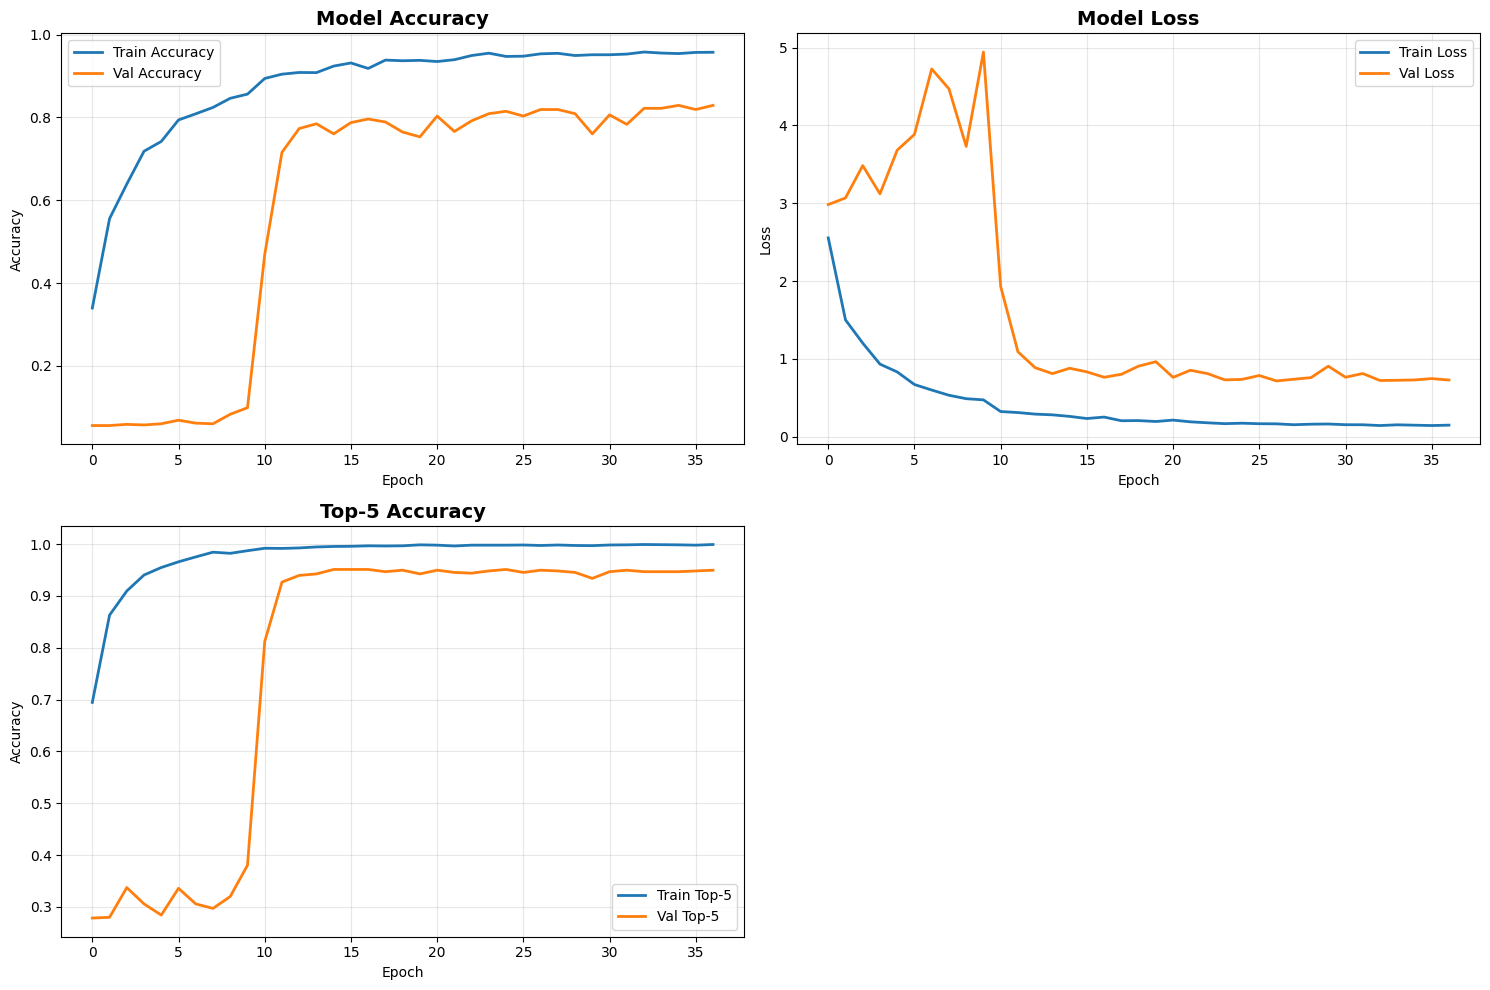

✓ Training history plotted successfully!


In [ ]:
def plot_training_history(history):
    """Plot training history"""

    # Check which metrics are available
    available_metrics = list(history.history.keys())
    has_precision = 'precision' in available_metrics
    has_recall = 'recall' in available_metrics
    has_top5 = 'top_5_accuracy' in available_metrics

    # Determine number of subplots needed
    num_plots = 2  # Always have accuracy and loss
    if has_top5:
        num_plots += 1
    if has_precision:
        num_plots += 1

    # Create subplots
    if num_plots == 2:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes = axes.flatten()
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

    plot_idx = 0

    # Accuracy
    axes[plot_idx].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[plot_idx].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[plot_idx].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[plot_idx].set_xlabel('Epoch')
    axes[plot_idx].set_ylabel('Accuracy')
    axes[plot_idx].legend()
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1

    # Loss
    axes[plot_idx].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[plot_idx].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[plot_idx].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[plot_idx].set_xlabel('Epoch')
    axes[plot_idx].set_ylabel('Loss')
    axes[plot_idx].legend()
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1

    # Top-5 Accuracy (if available)
    if has_top5 and plot_idx < len(axes):
        axes[plot_idx].plot(history.history['top_5_accuracy'], label='Train Top-5', linewidth=2)
        axes[plot_idx].plot(history.history['val_top_5_accuracy'], label='Val Top-5', linewidth=2)
        axes[plot_idx].set_title('Top-5 Accuracy', fontsize=14, fontweight='bold')
        axes[plot_idx].set_xlabel('Epoch')
        axes[plot_idx].set_ylabel('Accuracy')
        axes[plot_idx].legend()
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1

    # Precision (if available)
    if has_precision and plot_idx < len(axes):
        axes[plot_idx].plot(history.history['precision'], label='Train Precision', linewidth=2)
        axes[plot_idx].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
        axes[plot_idx].set_title('Model Precision', fontsize=14, fontweight='bold')
        axes[plot_idx].set_xlabel('Epoch')
        axes[plot_idx].set_ylabel('Precision')
        axes[plot_idx].legend()
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1

    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()

    # Save plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(CONFIG['MODEL_SAVE_PATH'], f'training_history_{timestamp}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

# Plot training history
plot_training_history(history)

print("✓ Training history plotted successfully!")

In [ ]:
print("=" * 60)
print("EVALUATING FINAL MODEL ON TEST SET")
print("=" * 60)

test_results = model.evaluate(test_gen, verbose=1)

metrics_names = model.metrics_names

print("\nTest Results:")
for name, value in zip(metrics_names, test_results):
    print(f"  {name}: {value:.4f}")

EVALUATING FINAL MODEL ON TEST SET
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.8185 - loss: 0.6966 - top_5_accuracy: 0.9612

Test Results:
  loss: 0.7176
  compile_metrics: 0.8137


Generating predictions for confusion matrix...
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 335ms/step


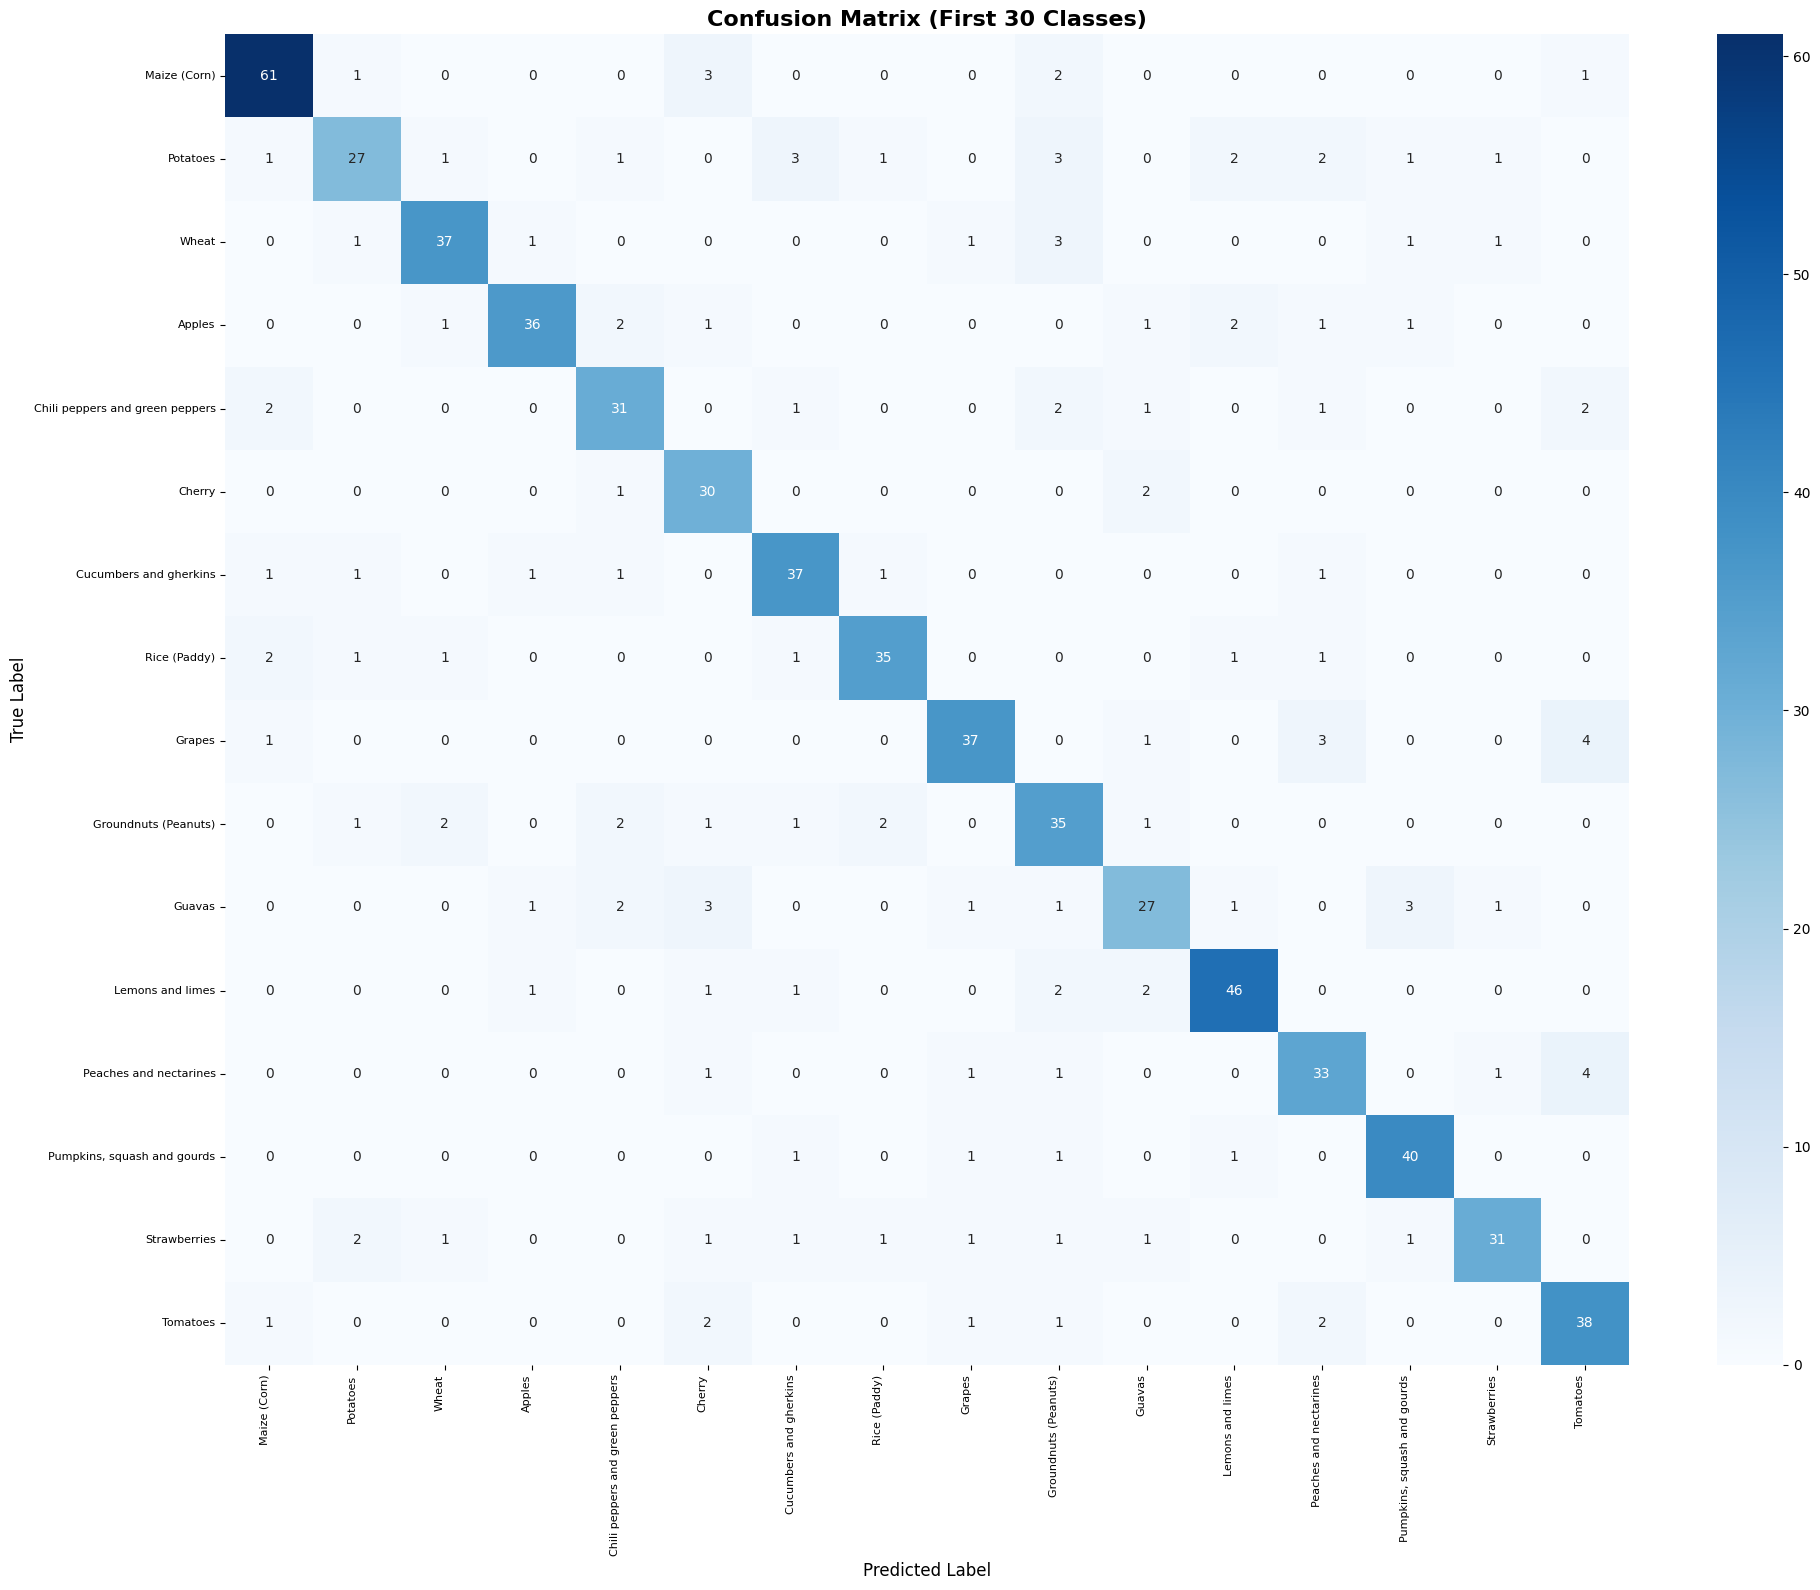

✓ Confusion matrix generated


In [ ]:
# Generate predictions
print("Generating predictions for confusion matrix...")
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix (first 30 classes for readability)
plt.figure(figsize=(20, 16))
sns.heatmap(
    cm[:30, :30],  # First 30 classes
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CROP_CLASSES[:30],
    yticklabels=CROP_CLASSES[:30]
)
plt.title('Confusion Matrix (First 30 Classes)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['MODEL_SAVE_PATH'], f'confusion_matrix_{timestamp}.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix generated")

In [ ]:
# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=CROP_CLASSES,
    digits=4
)

print("Classification Report:")
print("=" * 60)
print(report)

# Save report
report_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f'classification_report_{timestamp}.txt')
with open(report_path, 'w') as f:
    f.write(report)

print(f"\n✓ Classification report saved to: {report_path}")

Classification Report:
                                 precision    recall  f1-score   support

                   Maize (Corn)     0.8841    0.8971    0.8905        68
                       Potatoes     0.7941    0.6279    0.7013        43
                          Wheat     0.8605    0.8222    0.8409        45
                         Apples     0.9000    0.8000    0.8471        45
Chili peppers and green peppers     0.7750    0.7750    0.7750        40
                         Cherry     0.6977    0.9091    0.7895        33
         Cucumbers and gherkins     0.8043    0.8605    0.8315        43
                   Rice (Paddy)     0.8750    0.8333    0.8537        42
                         Grapes     0.8605    0.8043    0.8315        46
           Groundnuts (Peanuts)     0.6731    0.7778    0.7216        45
                         Guavas     0.7500    0.6750    0.7105        40
               Lemons and limes     0.8679    0.8679    0.8679        53
         Peaches and nectar

In [ ]:
# Save final model
final_model_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f'crop_classifier_final_{timestamp}.h5')
model.save(final_model_path)

print("=" * 60)
print("MODEL SAVED SUCCESSFULLY!")
print("=" * 60)
print(f"Model saved to: {final_model_path}")
print(f"Best model saved to: {checkpoint_path}")

# Save training history
history_dict = {
    key: [float(val) for val in values]
    for key, values in history.history.items()
}

history_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f'training_history_{timestamp}.json')
with open(history_path, 'w') as f:
    json.dump(history_dict, f, indent=4)

print(f"Training history saved to: {history_path}")

MODEL SAVED SUCCESSFULLY!
Model saved to: /content/drive/MyDrive/crop_models/crop_classifier_final_20260129_163021.h5
Best model saved to: /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5
Training history saved to: /content/drive/MyDrive/crop_models/training_history_20260129_163021.json


Testing on: /content/dataset_filtered/test/Strawberries plant/5821.jpg

Predictions for: /content/dataset_filtered/test/Strawberries plant/5821.jpg
1. Pumpkins, squash and gourds: 1.0000 (100.00%)
2. Maize (Corn): 0.0000 (0.00%)
3. Groundnuts (Peanuts): 0.0000 (0.00%)
4. Strawberries: 0.0000 (0.00%)
5. Grapes: 0.0000 (0.00%)

Image:


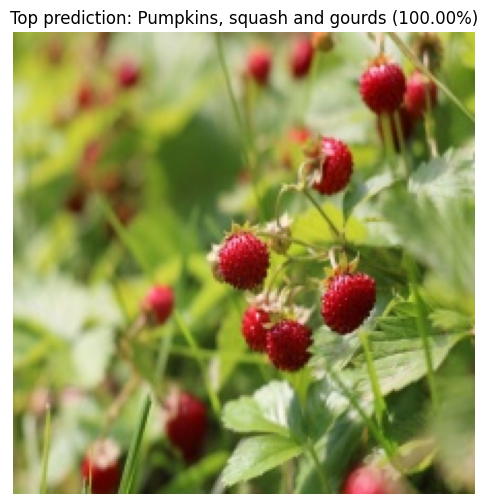

In [ ]:
import cv2
from PIL import Image
from google.colab.patches import cv2_imshow

def predict_single_image(image_path, model, top_k=5):
    """Predict crop for a single image"""
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']))
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)[0]

    # Get top-k predictions
    top_k_indices = predictions.argsort()[-top_k:][::-1]

    print(f"\nPredictions for: {image_path}")
    print("=" * 60)
    for i, idx in enumerate(top_k_indices, 1):
        print(f"{i}. {CROP_CLASSES[idx]}: {predictions[idx]:.4f} ({predictions[idx]*100:.2f}%)")

    # Display image
    print("\nImage:")
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.title(f"Top prediction: {CROP_CLASSES[top_k_indices[0]]} ({predictions[top_k_indices[0]]*100:.2f}%)")
    plt.axis('off')
    plt.show()

    return top_k_indices, predictions

# Example: Test on a random test image
test_class = os.listdir(os.path.join(CONFIG['DATASET_PATH'], 'test'))[0]
test_image_path = os.path.join(CONFIG['DATASET_PATH'], 'test', test_class,
                               os.listdir(os.path.join(CONFIG['DATASET_PATH'], 'test', test_class))[0])

print(f"Testing on: {test_image_path}")
top_indices, probs = predict_single_image(test_image_path, model, top_k=5)

In [ ]:
# Download the trained model
from google.colab import files

print("Preparing model for download...")
print(f"Best model: {checkpoint_path}")
print(f"Final model: {final_model_path}")

# Download best model
files.download(checkpoint_path)

print("\n✓ Model download started!")
print("The model file will be downloaded to your computer.")

Preparing model for download...
Best model: /content/drive/MyDrive/crop_models/crop_classifier_20260129_163021_best.h5
Final model: /content/drive/MyDrive/crop_models/crop_classifier_final_20260129_163021.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Model download started!
The model file will be downloaded to your computer.


In [ ]:
# Convert to TensorFlow Lite for mobile deployment
def convert_to_tflite(model, output_path):
    """Convert Keras model to TFLite"""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Optional: Quantization for smaller size
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    tflite_model = converter.convert()

    # Save
    with open(output_path, 'wb') as f:
        f.write(tflite_model)

    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"✓ TFLite model saved: {output_path}")
    print(f"  Model size: {size_mb:.2f} MB")

    return output_path

# Convert to TFLite
tflite_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f'crop_classifier_{timestamp}.tflite')
convert_to_tflite(model, tflite_path)

# Download TFLite model
files.download(tflite_path)

Saved artifact at '/tmp/tmprx7aqj3q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_492')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  137753128465616: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137753128466384: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137753308186576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308189264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308186960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308186384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308187536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308190032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308193680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137753308187152: TensorSpec(shape=(), dtype=tf.resource, name

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>